12 · Imagery: draping real pictures on the ground

Notebook 11 built a surface out of numbers; this one puts a photograph on it.
A graph over the aerial photograph of the place is a claim you can check by
looking: every edge either lies on a street or does not.

Ciutat Vella, València, the same 600 m as the rest of the suite. No API key:
thirteen tile sources and any WMS endpoint you name are open.

## 0 · Setup

In [1]:
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import math

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

ox = nb.osmnx()

CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600
METRIC_CRS = "EPSG:25830"

# Wider than the graph on purpose: the camera frames the graph plus a margin,
# so ground exactly as wide leaves a strip of backdrop down one side.
CONTEXT_RADIUS_M = 720

# 56 tiles and 0.92 m per pixel over this frame; section 2 measures why
# further zoom does not pay.
ZOOM = 17

### Switches

- `RUN_WMS`: one GetMap against a third-party endpoint that can be down.
  About 2.5 s and 4 MB when it is up. Off by default: a failure here is
  somebody else's outage.
- `RUN_ZOOM_18`: one extra drape at zoom 18, 182 tiles instead of 56 and about
  4.7 MB, for detail no figure at 900 px can show. Off by default.

In [2]:
RUN_WMS = False
RUN_ZOOM_18 = False

# Any WMS serving EPSG:4326 GetMap here works. The intended one is a national
# orthophoto service (Spain's PNOA, `OI.OrthoimageCoverage`), but it answered
# HTTP 502 every time this was measured, so the default is one that responds.
WMS_URL = "https://ows.terrestris.de/osm/service"
WMS_LAYER = "OSM-WMS"

## 1 · The catalog

`sg.context.imagery_sources()` lists what can be fetched without a key, with
the deepest zoom each service actually serves. Thirteen entries, four
providers, each drawn for a different job:

| Source | What it is for |
|---|---|
| `ESRI_IMAGERY` | Satellite: roofs, trees, car parks. The default when the figure has to be believed. |
| `ESRI_STREET` | Labeled road map. The alignment check: streets and graph edges are the same objects. |
| `ESRI_TOPO` | Relief shading plus roads and place names. |
| `ESRI_DARK_GRAY` | Dark canvas: coastlines, major roads, faint labels. A background for data. |
| `ESRI_LIGHT_GRAY` | The same for print, on white. |
| `ESRI_HILLSHADE` | Relief only. Pairs with a DEM figure. |
| `ESRI_OCEAN` | Bathymetry. Stops at zoom 13; over a city, a blue rectangle. |
| `ESRI_TERRAIN` | Small-scale shaded relief. Also stops at 13. |
| `OSM` | Standard OpenStreetMap rendering: dense, labeled, opinionated. |
| `OPENTOPOMAP` | Contours and hillshading over OSM data. |
| `CARTO_VOYAGER` | Colored basemap, quieter than OSM. |
| `CARTO_POSITRON` | Light canvas for data overlay. |
| `CARTO_DARK_MATTER` | Dark canvas for data overlay. |

Context against canvas is the split that matters: a satellite image is
high-frequency detail at every luminance and competes with whatever you draw
on it, where a canvas is deliberately empty and dim. Choosing the first when
you meant the second is the commonest way an overlay figure becomes
unreadable.

In [3]:
catalog = sg.context.imagery_sources()
print(f"\n{len(catalog)} sources, none of them needing a key")
check("every cataloged source is keyless", len(catalog) == 13)

  ESRI_IMAGERY       Esri · Satellite (World Imagery)   max zoom 19
  ESRI_STREET        Esri · Streets                     max zoom 19
  ESRI_TOPO          Esri · Topographic                 max zoom 19
  ESRI_DARK_GRAY     Esri · Dark Gray Canvas            max zoom 16
  ESRI_LIGHT_GRAY    Esri · Light Gray Canvas           max zoom 16
  ESRI_OCEAN         Esri · Ocean Base                  max zoom 13
  ESRI_HILLSHADE     Esri · Hillshade                   max zoom 16
  ESRI_TERRAIN       Esri · Terrain Base                max zoom 13
  OSM                OpenStreetMap · Standard           max zoom 19
  OPENTOPOMAP        OpenTopoMap · Topographic          max zoom 17
  CARTO_VOYAGER      CARTO · Voyager                    max zoom 20
  CARTO_POSITRON     CARTO · Positron (Light)           max zoom 20
  CARTO_DARK_MATTER  CARTO · Dark Matter                max zoom 20

13 sources, none of them needing a key
[PASS] every cataloged source is keyless


True

### What you owe them

Esri's terms of use, the OpenStreetMap tile usage policy and CARTO's basemap
terms all require the attribution string on anything published that uses the
tiles. `sg.context.imagery()` stores it on the terrain object and
`sg.context.attribution()` prints it.

The OSM policy also requires a User-Agent identifying the application, and
rules out bulk downloading. `sg.context` appends its own suffix to the
add-on's User-Agent during a fetch, caps a request at 256 tiles, and caches
every tile on disk.

In [4]:
for key in ("ESRI_IMAGERY", "OSM", "CARTO_POSITRON", "OPENTOPOMAP"):
    print(f"  {key:<16} {catalog[key]['attribution']}")

  ESRI_IMAGERY     Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community
  OSM              © OpenStreetMap contributors
  CARTO_POSITRON   © OpenStreetMap contributors © CARTO
  OPENTOPOMAP      © OpenStreetMap contributors, SRTM — © OpenTopoMap (CC-BY-SA)


## 2 · Zoom against tiles against seconds

A slippy-map zoom level doubles linear resolution, so it quadruples tiles.
`sg.context.imagery_estimate()` computes the budget without fetching
anything: the tile rectangle, how many are already on disk, and the composite
size.

In [5]:
bounds = sg.context.bounds_around(CENTER, CONTEXT_RADIUS_M)
span_m = 2 * CONTEXT_RADIUS_M

def meters_per_pixel(latitude, zoom):
    """Ground resolution of a Web Mercator tile pyramid, in meters.

    The equator is 40 075 016.686 m and level `z` covers it in `2**z x 256`
    pixels; the scale shrinks with the cosine of the latitude. Computed rather
    than read off `image_size`, because that field is the tile canvas, always a
    little larger than the rectangle actually asked for.
    """
    return 156543.03392 * math.cos(math.radians(latitude)) / (2 ** zoom)


print(f"{'zoom':>5} {'tiles':>7} {'m/px':>7} {'px across the frame':>21} "
      f"{'cached':>7}  limit")
for zoom in range(15, 20):
    estimate = sg.context.imagery_estimate(bounds, "ESRI_IMAGERY", zoom,
                                           verbose=False)
    resolution = meters_per_pixel(CENTER[0], zoom)
    print(f"{zoom:>5} {estimate['tiles']:>7} {resolution:>7.2f} "
          f"{span_m / resolution:>21.0f} {estimate['cached']:>7}  "
          f"{'REFUSED' if estimate['over_limit'] else 'ok'}")

over = sg.context.imagery_estimate(bounds, "ESRI_IMAGERY", 19, verbose=False)
check("zoom 19 is refused before it is requested", over["over_limit"],
      f"{over['tiles']} tiles against a ceiling of {sg.context.MAX_TILES}")

 zoom   tiles    m/px   px across the frame  cached  limit
   15       6    3.69                   390       6  ok
   16      20    1.84                   781       0  ok
   17      56    0.92                  1562      56  ok
   18     182    0.46                  3124       0  ok
   19     650    0.23                  6247       0  REFUSED
[PASS] zoom 19 is refused before it is requested — 650 tiles against a ceiling of 256


True

These renders are 900 px across a 1.44 km frame, 1.6 m per
rendered pixel, so zoom 17 at 0.92 m/px already carries more detail than the
render can show and zoom 18 quadruples the traffic for pixels that are
averaged away. Fetch zoom 18 once if you intend to crop in: a tile fetched
once is on disk under the system temp directory and never fetched again, so
the second run spends no network. Cold, the 56-tile zoom-17 request measured
about a second; warm, a fraction.

Per-source ceilings differ. Esri Ocean and Terrain stop at zoom 13; the two
gray canvases and Hillshade at 16; OpenTopoMap at 17. `fetch_basemap` clamps
silently, so asking Ocean for zoom 17 here returns zoom 13, about 15 m per
pixel, under a hundred pixels across 1.44 km, stretched over the whole
surface. `imagery_estimate` clamps first and says so, which is the only
warning you get.

In [6]:
for source in ("ESRI_IMAGERY", "ESRI_DARK_GRAY", "ESRI_OCEAN"):
    estimate = sg.context.imagery_estimate(bounds, source, ZOOM, verbose=False)
    note = (f"clamped from {estimate['zoom_requested']}"
            if estimate["zoom_clamped"] else "as requested")
    resolution = meters_per_pixel(CENTER[0], estimate["zoom"])
    print(f"  {source:<16} zoom {estimate['zoom']:>2} ({note:<16}) "
          f"{estimate['tiles']:>3} tiles, {resolution:>6.2f} m/px, "
          f"{span_m / resolution:>4.0f} px across the frame")

  ESRI_IMAGERY     zoom 17 (as requested    )  56 tiles,   0.92 m/px, 1562 px across the frame
  ESRI_DARK_GRAY   zoom 16 (clamped from 17 )  20 tiles,   1.84 m/px,  781 px across the frame
  ESRI_OCEAN       zoom 13 (clamped from 17 )   2 tiles,  14.75 m/px,   98 px across the frame


## 3 · The scene

A drive network over Ciutat Vella, with a ground surface under it. No
buildings: they are notebook 17's subject, and from overhead an extruded
footprint hides precisely the part of the photograph the graph is checked
against.

`add_context` does terrain, materials, imagery and vertical placement in one
call, and the order inside is load-bearing: `style_context()` calls
`data.materials.clear()`, so a drape applied before it is silently wiped and
what comes out is a gray plane that looks exactly like a failed fetch. Styling
first, drape second, `settle()` last because it needs the finished stack to
measure; it only moves Z, so the UVs survive, depending on XY alone.

Cost: one OSM download (cached after the first run), one elevation fetch of
about 1.5 s, one imagery fetch of about 1 s.

In [7]:
G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="drive", simplify=True)
nodes_ox, edges_ox = ox.graph_to_gdfs(G)

nodes = nodes_ox.to_crs(METRIC_CRS)[["geometry"]]
nodes.index.name = "node_id"

# OSMnx indexes edges by (u, v, key) because it allows parallel segments;
# `graph_to_blender` expects (source, target). Keep the shortest of each pair.
edges = (edges_ox.to_crs(METRIC_CRS).reset_index()
         .sort_values("length")
         .drop_duplicates(subset=["u", "v"])
         .set_index(["u", "v"])[["length", "geometry"]])

print(f"{len(nodes)} intersections, {len(edges)} segments, "
      f"{edges['length'].sum() / 1000:.1f} km")

sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(CENTER[0], CENTER[1], scale=0.001, name="Anchor_Imagery")
net = sg.graphs.from_gdf(nodes, edges, name="Street_Network", ref=anchor,
                         coll="SGNB_Imagery",
                         markers={"graph_type": "street_network"})
print(sg.graphs.summary(net))

193 intersections, 292 segments, 22.6 km
{'object': 'Street_Network', 'type': 'MESH', 'num_nodes': 193, 'num_edges': 279, 'is_directed': False, 'vertices': 193, 'mesh_edges': 279, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_length'], 'graph_type': 'street_network'}


In [8]:
# `"auto"`, not `"dem"`: the relief here is scenery, 27 m over 1.44 km, and
# `"dem"` raises when the elevation service is unreachable (open-elevation has
# timed out here). Notebook 11, where elevation is the subject, insists on it.
started = time.time()
ctx = sg.context.add_context(net, CENTER, CONTEXT_RADIUS_M, anchor,
                             buildings_gdf=False,
                             terrain_source="auto", resolution=24,
                             imagery="ESRI_IMAGERY", imagery_zoom=ZOOM)
print(f"\ncontext built in {time.time() - started:.1f} s")
sg.context.report(ctx["objects"])

surface = ctx["terrain"]
print("real elevation under the photograph:", ctx["real_elevation"])
if not ctx["real_elevation"]:
    print("  the elevation service was unreachable, so this is a flat plane;")
    print("  at 27 m of relief across 1.44 km the drape is unaffected either way")

check("the surface is wearing real imagery", ctx["real_imagery"],
      "False here means the fetch failed and the terrain fell back to the "
      "matte palette: gray because there is no photograph, rather than "
      "because the photograph is gray")

  open-elevation probe: unreachable (10.48 s, ReadTimeout: HTTPSConnectionPool(host='api.open-elevation.com', port=443): Read timed out. (read timeout=10.0))
  FALLING BACK TO A FLAT PLANE: open-elevation is unreachable (ReadTimeout: HTTPSConnectionPool(host='api.open-elevation.com', port=443): Read timed out. (read timeout=10.0)). This is NOT elevation data.
Creating terrain mesh: 2x2 vertices
Terrain mesh created: 4 vertices, 1 faces
  flat ground, 1440 x 1440 m (no elevation data)
  Esri · Satellite (World Imagery): 8x7 = 56 tiles at zoom 17, 2048x1792 px
  56 already cached, 0 to fetch (~0.0 MB)
Basemap: ESRI_IMAGERY z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z17_1787036002.png (1564×1564 px, 0/56 failed tiles)
scigraphs-utils available - Graphviz layouts enabled
  Esri · Satellite (World Imagery): 1564x1564 px in 0.4 s (56 tiles from cache)
  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User 

True

250 intersections on the aerial photograph of the streets they
are intersections of. Every node should sit on a junction, every edge should
follow a carriageway. The test is done by looking.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


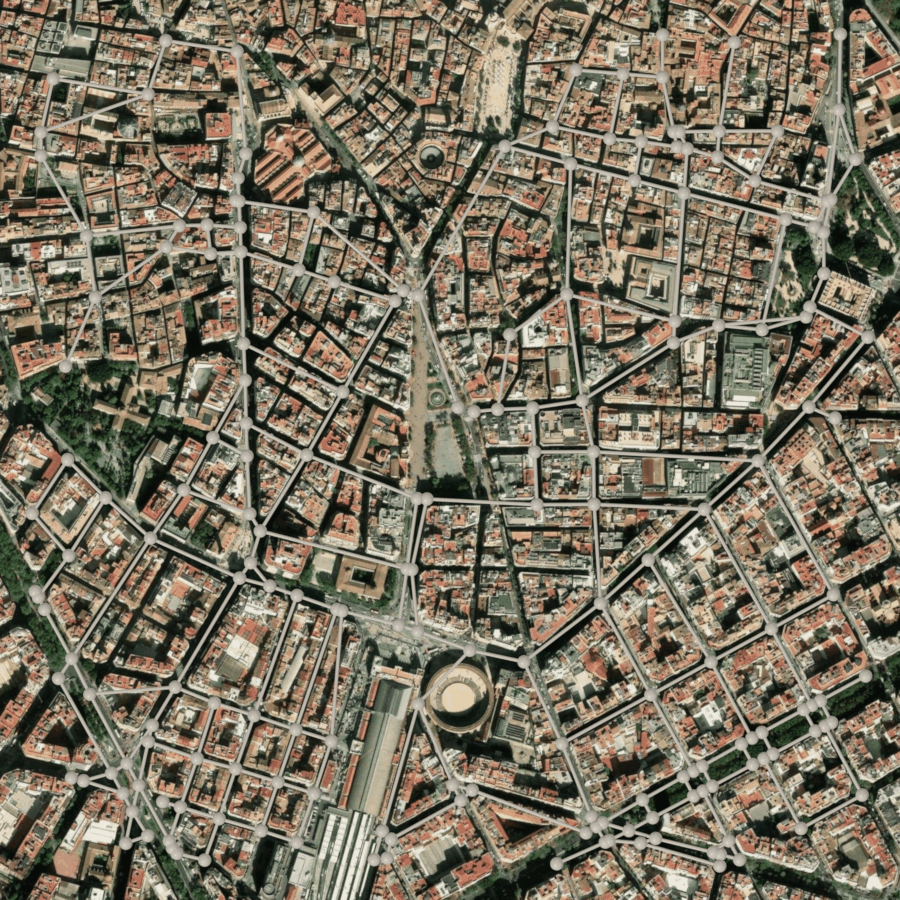

  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community


['Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community']

In [9]:
nb.figure(net, "renders/08_imagery/1_satellite",
          isolate=False, resolution=(900, 900), look='terrain',
          node_fraction=0.28, width=860, legible=False)
sg.context.attribution(ctx["objects"])

## 4 · The same graph on five other grounds

One drape per source, same camera, same graph; each answers a different
question. Cost: five fetches, 12 to 36 tiles each, a second or two apiece and
nothing at all on a re-run.

Basemap: ESRI_STREET z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_street_z17_1787036003.png (1564×1564 px, 0/56 failed tiles)
Esri · Streets                         zoom 17  56 tiles   0.4 s  (56 cached)
    a labeled road map, the alignment check
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


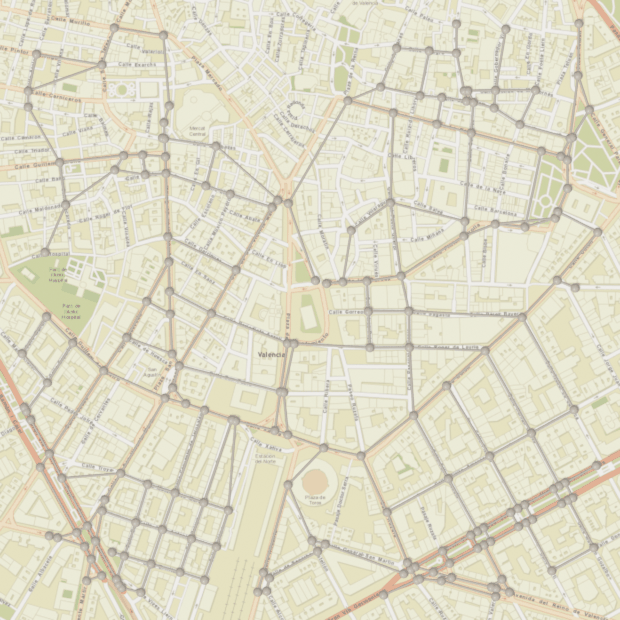

Basemap: ESRI_TOPO z=16 → 5×4=20 tiles (1280×1024 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_topo_z16_1787036003.png (782×781 px, 0/20 failed tiles)
Esri · Topographic                     zoom 16  20 tiles   0.1 s  (20 cached)
    relief plus roads and place names
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


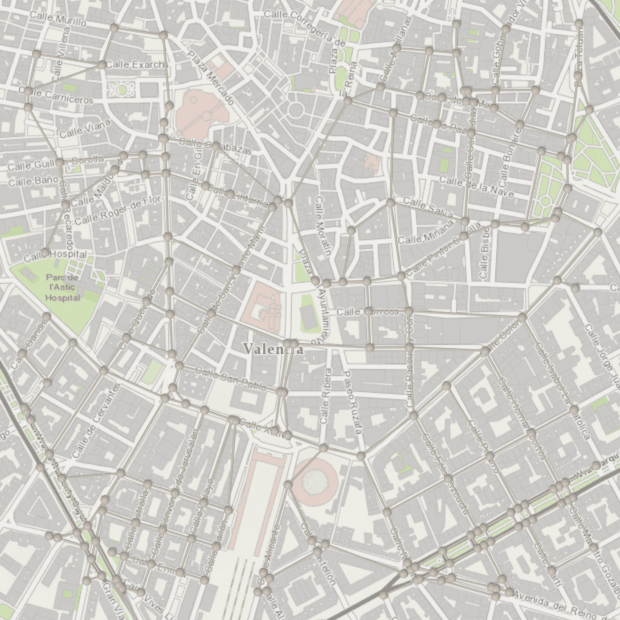

Basemap: CARTO_POSITRON z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_carto_positron_z17_1787036004.png (1564×1564 px, 0/56 failed tiles)
CARTO · Positron (Light)               zoom 17  56 tiles   0.2 s  (56 cached)
    light canvas: the data is the only ink
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


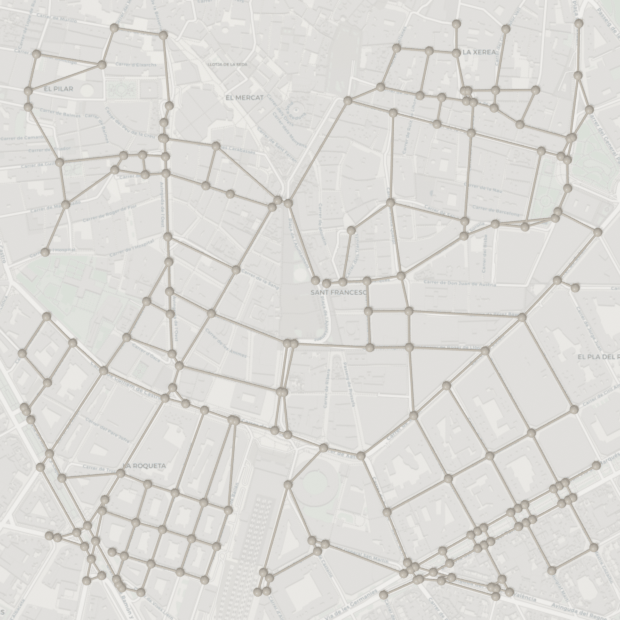

Basemap: CARTO_DARK_MATTER z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_carto_dark_matter_z17_1787036004.png (1564×1564 px, 0/56 failed tiles)
CARTO · Dark Matter                    zoom 17  56 tiles   0.2 s  (56 cached)
    dark canvas, same idea inverted
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


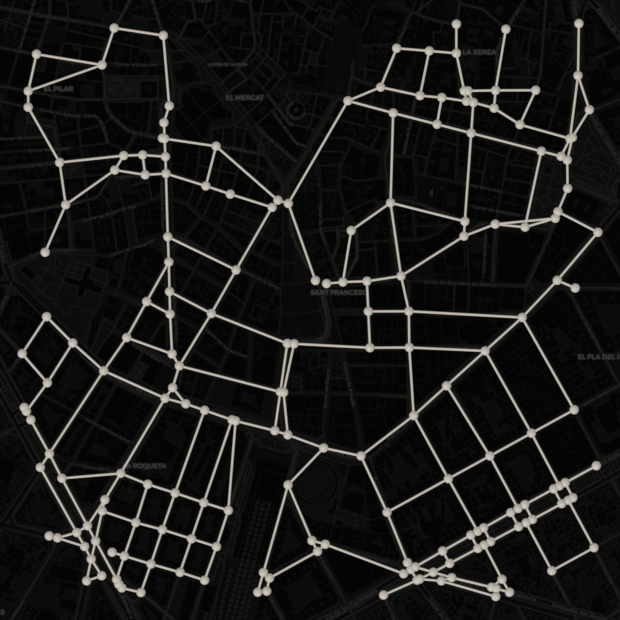

Basemap: ESRI_HILLSHADE z=16 → 5×4=20 tiles (1280×1024 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_hillshade_z16_1787036005.png (782×781 px, 0/20 failed tiles)
Esri · Hillshade                       zoom 16  20 tiles   0.1 s  (20 cached)
    relief alone, flat here by construction
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


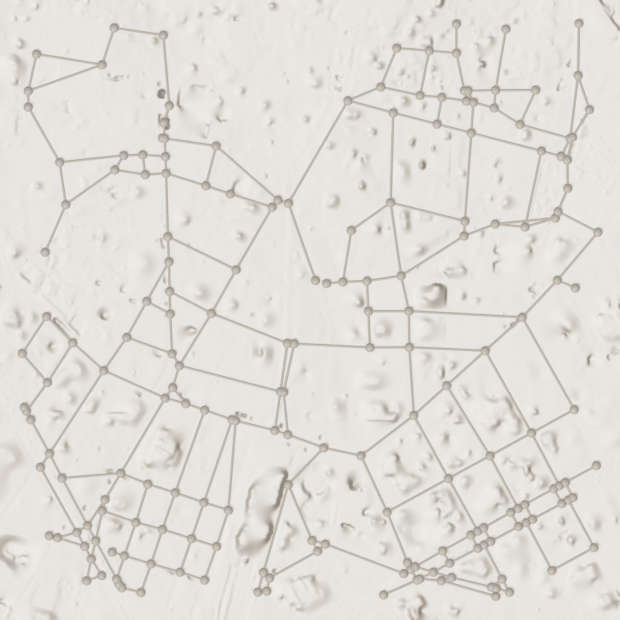

In [10]:
GALLERY = [
    ("ESRI_STREET", ZOOM, "a labeled road map, the alignment check"),
    ("ESRI_TOPO", 16, "relief plus roads and place names"),
    ("CARTO_POSITRON", ZOOM, "light canvas: the data is the only ink"),
    ("CARTO_DARK_MATTER", ZOOM, "dark canvas, same idea inverted"),
    ("ESRI_HILLSHADE", 16, "relief alone, flat here by construction"),
]

for source, zoom, purpose in GALLERY:
    result = sg.context.imagery(surface, source=source, zoom=zoom, verbose=False)
    # A down or rate-limiting tile server reports through `source_name=None`
    # rather than raising.
    if result.get("source_name") is None:
        print(f"{source:<38} unavailable: {result.get('error', 'no detail given')}")
        continue
    print(f"{result['source_name']:<38} zoom {result['zoom']:>2}  "
          f"{result['tiles']:>2} tiles  {result['seconds']:>4.1f} s  "
          f"({result['cached']} cached)")
    print(f"    {purpose}")
    nb.figure(net, f"renders/08_imagery/2_{source.lower()}",
              isolate=False, resolution=(620, 620), look='terrain',
              node_fraction=0.28, width=560, legible=False)

> **The equivalent operator.** In Blender the same fetch is
> `bpy.ops.scigraphs.osmnx_fetch_basemap()`, driven by
> `scene.scigraphs.osmnx_basemap_source`, `osmnx_basemap_zoom`,
> `osmnx_basemap_padding` and, for WMS, `osmnx_wms_url` / `osmnx_wms_layer`.
> Its `poll` demands an active object carrying `is_osmnx` and an attached
> terrain child, which a graph built from GeoDataFrames has neither of, so it
> cannot run here. `sg.context.imagery()` reaches the same two functions,
> `imagery.fetch_basemap` and `_project_uv_geographic`, without those
> preconditions: neither cares about anything but the terrain mesh and its DEM
> properties. The operator uses a 400-tile ceiling where this module uses 256.

## 5 · Alignment

The picture and the graph come from different services in different
projections and land in the same frame. One chain does it, per vertex:

1. `create_terrain_mesh` stamped `dem_center_lat`, `dem_center_lon` and
   `dem_scale` on the object: the parameters of the equirectangular-local
   projection it used.
2. `_project_uv_geographic` inverts that per vertex, world XY back to a real
   (lat, lon).
3. `imagery.latlon_to_image_uv` maps that into the image using the
   georeference the fetch produced, not the one requested: XYZ tiles snap to
   integer tile boundaries and the composite is cropped to whole pixels, so
   the two differ. `fetch_basemap` returns the rounded rectangle in Mercator
   tile units.
4. Two image projections, `WEB_MERCATOR` for XYZ tiles and `WGS84_LINEAR` for
   a WMS `GetMap` in EPSG:4326, each with its own inverse.

So the fetched box need not match the mesh: ask with `padding=0.25` and you
get a wider photograph the mesh maps into the middle of, still aligned. What
must match is the mesh's own record of where it is. The corners are the cheap
check.

In [11]:
from scigraphs_core.geo import imagery as sg_imagery

terrain_box = {k: float(surface[f"dem_bounds_{k}"])
               for k in ("north", "south", "east", "west")}
_image, metadata = sg_imagery.fetch_basemap(bounds=terrain_box,
                                            source="ESRI_STREET", zoom=ZOOM)

corners = {"NW": (terrain_box["north"], terrain_box["west"]),
           "NE": (terrain_box["north"], terrain_box["east"]),
           "SW": (terrain_box["south"], terrain_box["west"]),
           "SE": (terrain_box["south"], terrain_box["east"])}
print(f"projection: {metadata['projection']}")
uvs = {}
for name, (lat, lon) in corners.items():
    uvs[name] = sg_imagery.latlon_to_image_uv(lat, lon, metadata)
    print(f"  {name}  u={uvs[name][0]:+.5f}  v={uvs[name][1]:+.5f}")

worst = max(abs(value - round(value)) for uv in uvs.values() for value in uv)
check("the terrain's corners land on the image's corners", worst < 1e-3,
      f"largest deviation from 0 or 1 is {worst:.2e} in UV, which over "
      f"{2 * CONTEXT_RADIUS_M:.0f} m is {worst * 2 * CONTEXT_RADIUS_M * 100:.2f} cm")

Basemap: ESRI_STREET z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_street_z17_1787036005.png (1564×1564 px, 0/56 failed tiles)
projection: WEB_MERCATOR
  NW  u=+0.00031  v=+0.99979
  NE  u=+1.00007  v=+0.99979
  SW  u=+0.00031  v=+0.00003
  SE  u=+1.00007  v=+0.00003
[PASS] the terrain's corners land on the image's corners — largest deviation from 0 or 1 is 3.12e-04 in UV, which over 1440 m is 44.98 cm


True

### What the numeric check can and cannot see

`sg.context.check_alignment()` compares bounding boxes in Blender XY: how
far the context's center is from the graph's, as a fraction of the graph's
diagonal, and how much of the graph falls inside the context. It catches a
wrong anchor and a wrong scale, both common.

It cannot catch a wrong photograph, because the photograph is not geometry:
the mesh has not moved, only the pixels on it are of somewhere else. The next
two cells corrupt the recorded georeference by 250 m, the failure a terrain
from one source and a bounding box from another produces.

Basemap: ESRI_STREET z=17 → 8×8=64 tiles (2048×2048 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_street_z17_1787036006.png (1564×1564 px, 0/64 failed tiles)
[PASS] Context_Ground aligned with Street_Network — center off by 0.0061 BU (0.35% of the graph diagonal), covers 100.0% of it, 1.19x its width
[PASS] the numeric check passes on a drape that is 250 m out — which is the point: it is measuring the mesh, and the mesh is where it always was
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


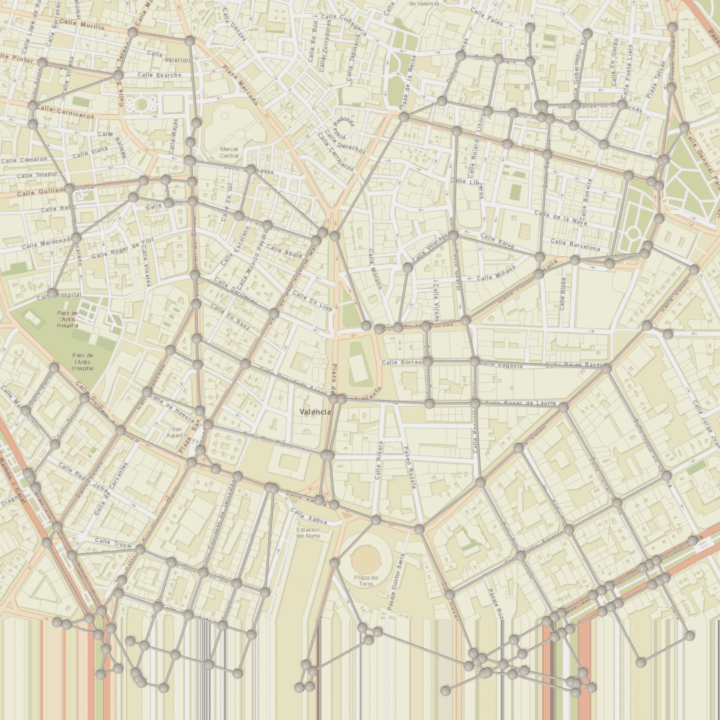

In [12]:
recorded = dict(terrain_box)
shift_deg = 250.0 * 180.0 / (math.pi * 6371000.0)
surface["dem_bounds_north"] = recorded["north"] + shift_deg
surface["dem_bounds_south"] = recorded["south"] + shift_deg

sg.context.imagery(surface, source="ESRI_STREET", zoom=ZOOM, verbose=False)
alignment = sg.context.check_alignment(net, [surface])

check("the numeric check passes on a drape that is 250 m out",
      bool(alignment and alignment["ok"]),
      "which is the point: it is measuring the mesh, and the mesh is "
      "where it always was")

nb.figure(net, "renders/08_imagery/3_misaligned",
          isolate=False, resolution=(720, 720), look='terrain',
          node_fraction=0.28, width=660, legible=False)

Compare that frame with the next. Two tells, and the second is
the reliable one.

The alignment itself: the network runs across the blocks instead of along the
streets, uniformly, everywhere. 250 m out of 1400 is a sixth of the frame,
obvious once you follow a named street and easy to miss at a glance.

The band of vertical streaks along the bottom edge. The photograph was fetched
for a rectangle 250 m further north than the mesh, so the southern sixth has
no image under it; the texture node's `EXTEND` mode repeats the last row of
pixels, and a repeated row of a street map is a comb of colored verticals.
Any smeared edge in a drape means the mesh is asking for pixels the image does
not have: always a georeference disagreement, never a rendering artifact.

The signature says which. A rigid shift is a wrong bounding box. A stretch
that grows toward one edge is a wrong projection: a Web Mercator image mapped
as if linear in latitude does exactly that, zero error at the center, worst at
top and bottom. A rotation means the anchor latitude is wrong enough to change
the longitude scaling.

Basemap: ESRI_STREET z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_street_z17_1787036006.png (1564×1564 px, 0/56 failed tiles)
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


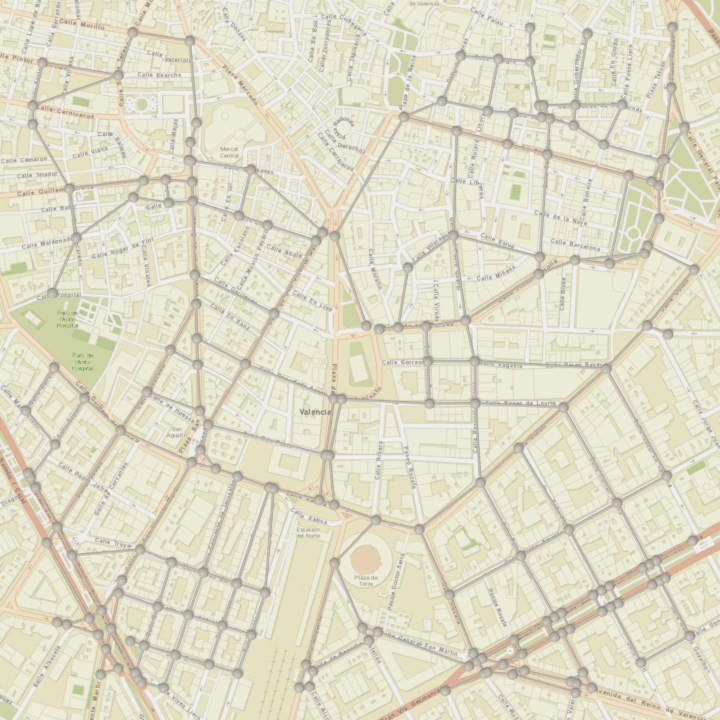

In [13]:
for key, value in recorded.items():
    surface[f"dem_bounds_{key}"] = value

sg.context.imagery(surface, source="ESRI_STREET", zoom=ZOOM, verbose=False)
nb.figure(net, "renders/08_imagery/4_aligned",
          isolate=False, resolution=(720, 720), look='terrain',
          node_fraction=0.28, width=660, legible=False)

## 6 · Zoom, seen rather than estimated

Zoom 15 against zoom 17 over the same frame: six tiles against fifty-six,
3.7 m per pixel against 0.92. At the size these figures are shown, the
difference is the individual buildings.

Basemap: ESRI_IMAGERY z=15 → 3×2=6 tiles (768×512 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z15_1787036007.png (391×391 px, 0/6 failed tiles)
zoom 15: 6 tiles, 391 x 391 px, 0.02 s
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


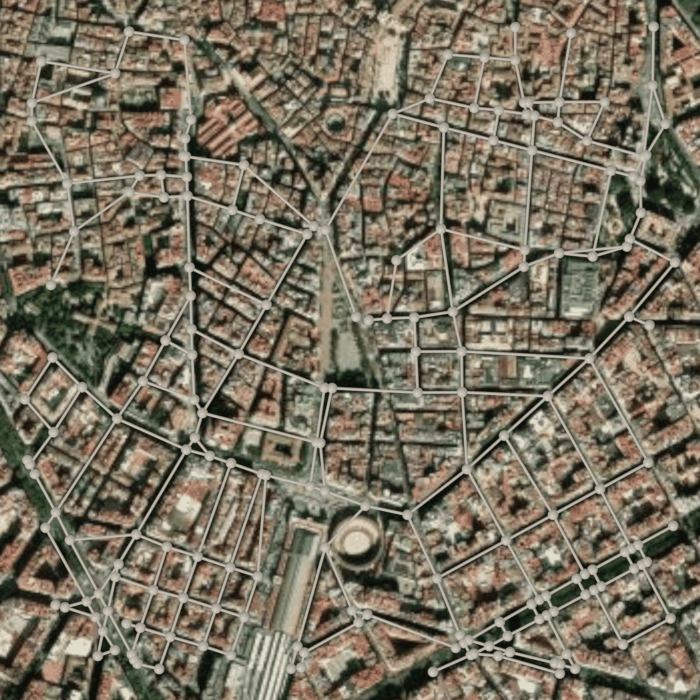

Basemap: ESRI_IMAGERY z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z17_1787036008.png (1564×1564 px, 0/56 failed tiles)
zoom 17: 56 tiles, 1564 x 1564 px, 0.35 s
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


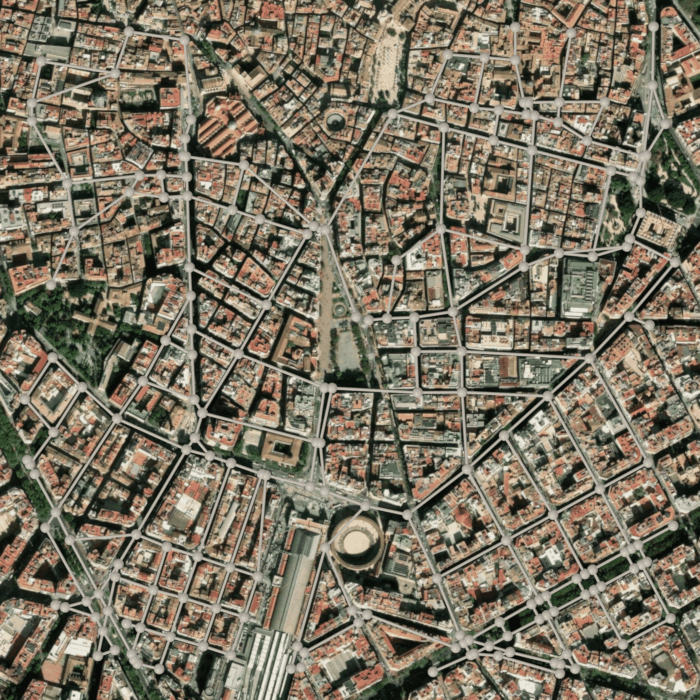


RUN_ZOOM_18 is off: 132 tiles for detail this render size cannot show. Turn it on when you intend to crop in.


In [14]:
for zoom in (15, ZOOM):
    result = sg.context.imagery(surface, source="ESRI_IMAGERY", zoom=zoom,
                                verbose=False)
    print(f"zoom {zoom}: {result['tiles']} tiles, "
          f"{result['image_size'][0]} x {result['image_size'][1]} px, "
          f"{result['seconds']:.2f} s")
    nb.figure(net, f"renders/08_imagery/5_zoom_{zoom}",
              isolate=False, resolution=(700, 700), look='terrain',
              node_fraction=0.28, width=640, legible=False)

if RUN_ZOOM_18:
    result = sg.context.imagery(surface, source="ESRI_IMAGERY", zoom=18,
                                verbose=False)
    print(f"zoom 18: {result['tiles']} tiles, "
          f"{result['image_size'][0]} x {result['image_size'][1]} px, "
          f"{result['seconds']:.1f} s")
    nb.figure(net, "renders/08_imagery/5_zoom_18",
              isolate=False, resolution=(700, 700), look='terrain',
              node_fraction=0.28, width=640, legible=False)
else:
    print("\nRUN_ZOOM_18 is off: 132 tiles for detail this render size "
          "cannot show. Turn it on when you intend to crop in.")

## 7 · A refusal

`imagery()` prints the estimate before it spends anything and refuses over
`MAX_TILES`. Not an exception: it returns `ok=False` with an error naming the
count and the fix, and leaves the existing drape in place. A request that
failed is no reason to throw away a photograph that succeeded.

In [15]:
refused = sg.context.imagery(surface, source="ESRI_IMAGERY", zoom=19,
                             verbose=False)
print("ok:", refused["ok"])
print("error:", refused["error"])
print("still wearing imagery:", sg.context.has_imagery(surface),
      "-", surface.get("scigraphs_imagery_name"))

check("a refused fetch leaves the previous drape alone",
      refused["ok"] is False and sg.context.has_imagery(surface))

  REFUSING TO FETCH: 650 tiles at zoom 19 is over the 256-tile ceiling; lower `zoom` (each step down quarters the count) or shrink the radius
  keeping the drape already on Context_Ground: Esri · Satellite (World Imagery). It is left over from an earlier call, not the result of this one.
ok: False
error: 650 tiles at zoom 19 is over the 256-tile ceiling; lower `zoom` (each step down quarters the count) or shrink the radius
still wearing imagery: True - Esri · Satellite (World Imagery)
[PASS] a refused fetch leaves the previous drape alone


True

## 8 · The custom WMS route

XYZ tiles are one protocol. The other is WMS, how national mapping agencies
publish orthophotography: one `GetMap` request, one image, your choice of
bounding box and pixel size, in a CRS you name. SciGraphs sends
`VERSION=1.3.0`, `CRS=EPSG:4326`, a 2048 × 2048 raster and the bbox in
latitude-first order, which is what 1.3.0 requires for that CRS and a common
source of blank images against servers that expect the 1.1.1 order.

The image comes back linear in latitude and longitude rather than Web
Mercator; `latlon_to_image_uv` handles that as `WGS84_LINEAR`, a plain bbox
rescale. Nothing else in the drape changes.

The default endpoint below is an OSM-rendered WMS, standing in for the PNOA
orthophoto that answered HTTP 502 on every attempt. It stamps a grid of
advertising watermarks across its free tier: in the drape, not a fault in the
projection, and a reminder that a public WMS is somebody else's server. Point
`WMS_URL` at your own and they go away.

In [16]:
if RUN_WMS:
    started = time.time()
    result = sg.context.imagery(surface, source="WMS", wms_url=WMS_URL,
                                wms_layer=WMS_LAYER, verbose=True)
    if result["ok"]:
        print(f"  {result['image_size'][0]} x {result['image_size'][1]} px in "
              f"{time.time() - started:.1f} s")
        nb.figure(net, "renders/08_imagery/6_wms",
                  isolate=False, resolution=(720, 720),
                  look='terrain', node_fraction=0.28, width=660,
                  legible=False)
    else:
        print("  the endpoint did not answer; the terrain kept what it had")
else:
    print(f"RUN_WMS is off. It would send one GetMap to {WMS_URL} "
          f"for layer {WMS_LAYER!r}: about 2.5 s and 4 MB when that host is up.")

RUN_WMS is off. It would send one GetMap to https://ows.terrestris.de/osm/service for layer 'OSM-WMS': about 2.5 s and 4 MB when that host is up.


## 9 · The cache

Every tile is written to disk under the system temp directory, keyed by
source, zoom and tile index, and read from there next time. That is what makes
a re-run free and the usage policies survivable. The stitched composites live
in the same tree and dominate the byte count: one 1564 x 1564 PNG is several
megabytes against about 26 kB for a tile.

In [17]:
cache_root, files, total_bytes = sg.context.imagery_cache_dir()
print(f"{files} files, {total_bytes / 1e6:.1f} MB")
print("under the system temp directory; `sg.context.clear_imagery_cache()` "
      "empties it")

428 files, 514.6 MB
under the system temp directory; `sg.context.clear_imagery_cache()` empties it


## 10 · The last figure

Back to satellite, at zoom 17, overhead like every other figure in the suite.

There is no raking second frame to show that the picture sits on a surface and
not on a plane. A couple of dozen meters of relief across 1.44 km is under two
percent of the frame, and an oblique camera does not rescue a number that
small. Notebook 11 reads relief from straight overhead with a low sun and an
elevation tint, from Granada; a hillshade of Ciutat Vella is a blank. What is
left here is the measurement below, of a real DEM.

Basemap: ESRI_IMAGERY z=17 → 8×7=56 tiles (2048×1792 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z17_1787036009.png (1564×1564 px, 0/56 failed tiles)
the surface under the photograph: 0 m of relief across 1440 m
  0.0% of the frame's width, and real elevation: False
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added


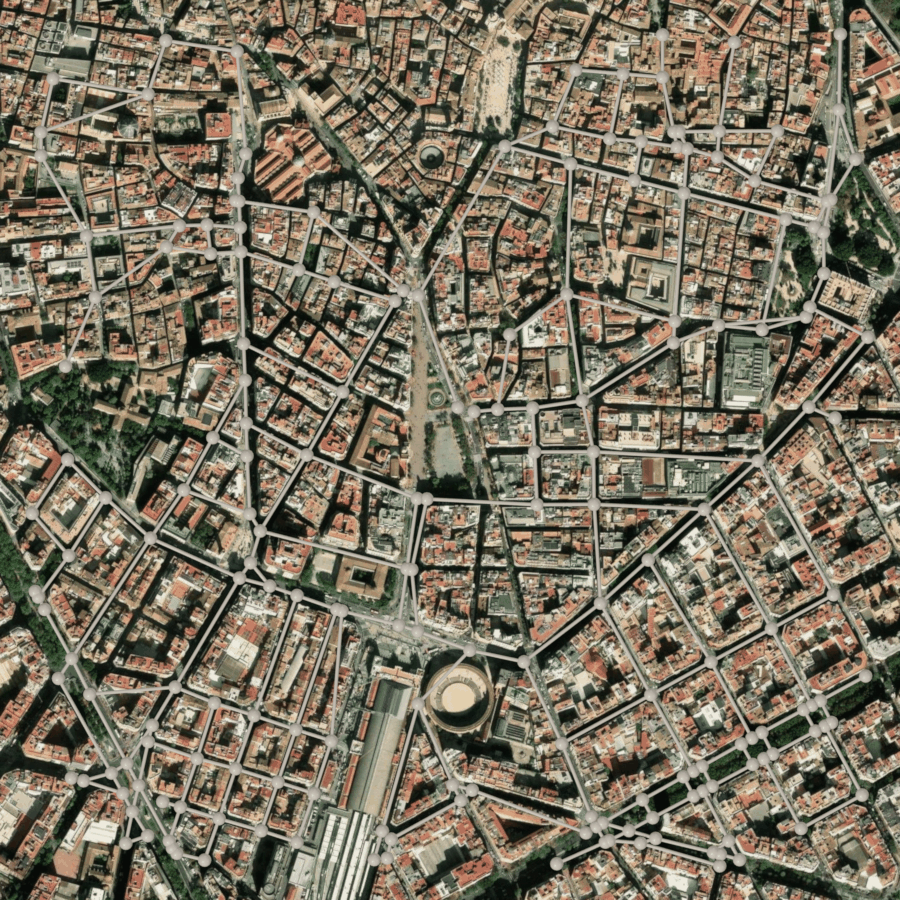

[PASS] 7_satellite_overhead.png legible — 92.2% ink (healthy range 0.5–100%)

attribution required on anything published from this notebook:
  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community


['Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community']

In [18]:
sg.context.imagery(surface, source="ESRI_IMAGERY", zoom=ZOOM, verbose=False)

box = sg.context.bbox(surface)
print(f"the surface under the photograph: {box['size'][2] / 0.001:.0f} m of "
      f"relief across {box['size'][0] / 0.001:.0f} m")
print(f"  {box['size'][2] / box['size'][0] * 100:.1f}% of the frame's width, "
      "and real elevation:", sg.context.is_real_elevation(surface))

path = nb.render(net, "renders/08_imagery/7_satellite_overhead",
                 isolate=False, resolution=(900, 900),
                 look='terrain', node_fraction=0.28,
                 ground=surface, verbose=False)
nb.show(path)
# The photograph covers the frame, so the 60 % ink ceiling would fail every
# drape here.
nb.check_render(path, maximum=0.995)

print("\nattribution required on anything published from this notebook:")
sg.context.attribution(ctx["objects"])

## 11 · Saving

In [19]:
output_dir = nb.out("12_imagery")
output_dir.mkdir(parents=True, exist_ok=True)

rows = ["zoom,tiles,meters_per_pixel,pixels_across_frame,over_limit"]
for zoom in range(15, 20):
    estimate = sg.context.imagery_estimate(bounds, "ESRI_IMAGERY", zoom,
                                           verbose=False)
    resolution = meters_per_pixel(CENTER[0], zoom)
    rows.append(f"{zoom},{estimate['tiles']},{resolution:.3f},"
                f"{span_m / resolution:.0f},{estimate['over_limit']}")
(output_dir / "zoom_cost.csv").write_text("\n".join(rows) + "\n", encoding="utf-8")

rows = ["source,provider,max_zoom,attribution"]
for key, info in catalog.items():
    rows.append(f'{key},{info["provider"]},{info["max_zoom"]},'
                f'"{info["attribution"]}"')
(output_dir / "imagery_sources.csv").write_text("\n".join(rows) + "\n",
                                                encoding="utf-8")

print("written to", nb.rel(output_dir))
for entry in sorted(output_dir.iterdir()):
    print("  ", entry.name, f"{entry.stat().st_size / 1e3:.1f} kB")

written to notebooks/out/12_imagery
   imagery_sources.csv 1.3 kB
   zoom_cost.csv 0.2 kB


## Summary

| Question | Call |
|---|---|
| What can I drape without a key? | `sg.context.imagery_sources()` |
| What will it cost? | `sg.context.imagery_estimate(bounds, source, zoom)` |
| Drape it | `sg.context.imagery(terrain, source=..., zoom=...)` |
| Terrain and drape in one call | `terrain(..., imagery=...)`, `add_context(..., imagery=...)` |
| Did it really work? | `sg.context.has_imagery(terrain)` |
| What must I credit? | `sg.context.attribution(objects)` |
| Inside Blender | `bpy.ops.scigraphs.osmnx_fetch_basemap()` |